# Pipeline de Pré-processamento e Preparação de Dados

Este notebook consolida a limpeza de dados iniciada na EDA (Issue #4) e prepara os conjuntos de treino, validação e teste para o treinamento dos modelos de classificação (Issue #5).

## Objetivos:
1. Realizar o tratamento de valores nulos.
2. Converter o alvo categórico para numérico.
3. Escalonar os atributos físicos.
4. Dividir os dados em proporção 70/15/15.

In [1]:
import pandas as pd  # Importa Pandas para manipulação tabularimport numpy as np  # Importa NumPy para operações numéricasimport matplotlib.pyplot as plt  # Importa Matplotlib para gráficosimport seaborn as sns  # Importa Seaborn para visualizações estilizadasfrom sklearn.model_selection import train_test_split  # Importa função de divisão treino/testefrom sklearn.metrics import ConfusionMatrixDisplay  # Importa funções de avaliação de métricasfrom sklearn.preprocessing import StandardScaler, LabelEncoder  # Importa ferramentas de pré-processamentofrom sklearn.linear_model import LogisticRegression  # Importa modelo de Regressão Logísticafrom sklearn.neural_network import MLPClassifier  # Importa a rede neural MLP do scikit-learnfrom sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score  # Importa funções de avaliação de métricas
# Configurações
pd.set_option('display.max_columns', None)  # Configura opções de exibição do Pandasplt.style.use('ggplot')  # Aplica estilo visual global ao Matplotlib

## 1. Carga dos Dados
Utilizaremos a URL oficial para garantir a consistência com a etapa anterior.

In [2]:
url = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv'  # Define a URL de acesso via TAP ao Exoplanet Archivedf_raw = pd.read_csv(url)  # Baixa dados do Exoplanet Archive via TAP (URL)print(f"Dataset carregado: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas")  # Exibe dimensões do dataset carregado

Dataset carregado: 9564 linhas e 153 colunas


## 2. Seleção de Atributos e Limpeza Inicial
Identificamos na EDA que algumas colunas são totalmente nulas ou são apenas IDs/metadados que não contribuem para a física do problema.

In [3]:
# Definindo o alvo
target = 'koi_pdisposition'  # Define a coluna alvo da classificação
# Colunas para remover (IDs e metadados irrelevantes para treinamento)
cols_to_drop = [  # Lista de colunas irrelevantes a remover (IDs e metadados)    'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 
    'koi_tce_delivname', 'koi_fittype', 'ra_str', 'dec_str'
]

# Identificando colunas com mais de 50% de valores nulos (conforme observado na EDA)
null_threshold = 0.5 * len(df_raw)  # Limite de 50% de nulos para remoção de colunahigh_null_cols = df_raw.columns[df_raw.isnull().sum() > null_threshold].tolist()  # Soma os valores nulos por coluna
total_drop = list(set(cols_to_drop + high_null_cols))  # Lista de colunas irrelevantes a remover (IDs e metadados)df = df_raw.drop(columns=total_drop)  # Combina lista de colunas para remoção
print(f"Colunas removidas: {len(total_drop)}")  # Combina lista de colunas para remoçãoprint(f"Novo formato: {df.shape}")  # Retorna (linhas, colunas) do dataframe

Colunas removidas: 32
Novo formato: (9564, 121)


## 3. Encoding e Tratamento de Nulos
Transformaremos o alvo em binário (1 e 0) e aplicaremos a mediana nos valores ausentes dos atributos numéricos.

In [4]:
# Encoding do alvo
le = LabelEncoder()  # Cria codificador de rótulos categóricosdf[target] = le.fit_transform(df[target])  # Aprende e transforma rótulos CANDIDATE/FALSE POSITIVE → 0/1print(f"Classes mapeadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")  # Transforma categorias usando mapeamento já aprendido
# Imputação pela mediana em colunas numéricas
df_numeric = df.select_dtypes(include=[np.number])  # Seleciona apenas colunas numéricasdf_final = df_numeric.fillna(df_numeric.median())  # Preenche nulos com a mediana de cada coluna
print(f"Nulos remanescentes: {df_final.isnull().sum().sum()}")  # Soma os valores nulos por coluna

Classes mapeadas: {'CANDIDATE': np.int64(0), 'FALSE POSITIVE': np.int64(1)}
Nulos remanescentes: 0


## 4. Divisão dos Dados (Split)
Dividiremos em 70% Treino, 15% Validação e 15% Teste.

In [5]:
X = df_final.drop(columns=[target])  # Remove as colunas especificadasy = df_final[target]  # Extrai a coluna alvo como variável dependente
# Primeiro split: Treino vs Resto (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)  # Primeiro split: 70% treino, 30% restante
# Segundo split: Validação vs Teste (50% do Resto = 15% cada)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)  # Segundo split: divide 30% em 15% validação e 15% teste
print(f"Treino: {X_train.shape}")  # Retorna (linhas, colunas) do dataframeprint(f"Validação: {X_val.shape}")  # Retorna (linhas, colunas) do dataframeprint(f"Teste: {X_test.shape}")  # Retorna (linhas, colunas) do dataframe

Treino: (6694, 108)
Validação: (1435, 108)
Teste: (1435, 108)


## 5. Escalonamento (Scaling)
Padronização é vital para o bom desempenho da MLP.

In [6]:
scaler = StandardScaler()  # Cria o padronizador (média=0, desvio=1)X_train_scaled = scaler.fit_transform(X_train)  # Aprende e aplica escalonamento no treinoX_val_scaled = scaler.transform(X_val)  # Escala validação com parâmetros do treinoX_test_scaled = scaler.transform(X_test)  # Escala teste com parâmetros do treino
print("Escalonamento concluído com StandardScaler.")  # Confirma conclusão do escalonamento

Escalonamento concluído com StandardScaler.


## 6. Treinamento do Modelo Baseline (Issue #6)
Utilizaremos a **Regressão Logística** como nosso modelo base (benchmark).

In [7]:
# Instanciando o modelo
baseline = LogisticRegression(max_iter=1000, random_state=42)  # Cria modelo baseline de Regressão Logísticabaseline.fit(X_train_scaled, y_train)  # Treina a Regressão Logística com dados de treino
y_pred_base = baseline.predict(X_val_scaled)  # Gera predições da Regressão no conjunto de validaçãoacc_base = accuracy_score(y_val, y_pred_base)  # Calcula acurácia do baseline na validaçãof1_base = f1_score(y_val, y_pred_base, average='weighted')  # Calcula F1-score ponderado do baseline
print(f"Baseline treinado! Acurácia: {acc_base:.4f} | F1: {f1_base:.4f}")  # Exibe métricas do modelo baseline

Baseline treinado! Acurácia: 0.9345 | F1: 0.9345


## 7. Implementação da Rede Neural MLP v1 (Issue #7)
Primeira versão com arquitetura padrão.

In [8]:
mlp_v1 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True)  # Cria rede MLP v1: 1 camada, 100 neurônios, ReLU, Adammlp_v1.fit(X_train_scaled, y_train)  # Treina a MLP v1 com os dados de treino
y_pred_v1 = mlp_v1.predict(X_val_scaled)  # Gera predições da MLP v1 na validaçãoacc_v1 = accuracy_score(y_val, y_pred_v1)  # Calcula acurácia da MLP v1f1_v1 = f1_score(y_val, y_pred_v1, average='weighted')  # Calcula F1-score ponderado da MLP v1
print(f"MLP v1 treinada! Acurácia: {acc_v1:.4f} | F1: {f1_v1:.4f}")  # Exibe métricas da MLP v1

MLP v1 treinada! Acurácia: 0.9833 | F1: 0.9833


## 8. Experimentos de Refinamento (Issue #8)
Testando variações de arquitetura e regularização.

In [9]:
# Experimento A: Arquitetura Profunda (2 camadas)
mlp_a = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)  # Cria MLP Exp A: 2 camadas (100+50 neurônios)mlp_a.fit(X_train_scaled, y_train)  # Treina o Exp A com dados de treinoacc_a = accuracy_score(y_val, mlp_a.predict(X_val_scaled))  # Calcula acurácia do Exp A
# Experimento B: Arquitetura Larga (200 neurônios)
mlp_b = MLPClassifier(hidden_layer_sizes=(200,), max_iter=500, random_state=42, early_stopping=True)  # Cria MLP Exp B: 1 camada com 200 neurôniosmlp_b.fit(X_train_scaled, y_train)  # Treina o Exp B com dados de treinoacc_b = accuracy_score(y_val, mlp_b.predict(X_val_scaled))  # Calcula acurácia do Exp B
# Experimento C: Regularização Forte (Alpha=0.01)
mlp_c = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.01, max_iter=500, random_state=42, early_stopping=True)  # Cria MLP Exp C: regularização L2 (alpha=0.01)mlp_c.fit(X_train_scaled, y_train)  # Treina o Exp C com dados de treinoacc_c = accuracy_score(y_val, mlp_c.predict(X_val_scaled))  # Calcula acurácia do Exp C
print("Experimentos concluídos!")  # Confirma fim dos experimentos

Experimentos concluídos!


## 9. Tabela Comparativa Consolidada
Resumo de todos os testes realizados.

In [10]:
results = pd.DataFrame({  # Cria DataFrame com resultados de todos os modelos    'Modelo': ['Baseline (LR)', 'MLP v1 (100)', 'Exp A (100, 50)', 'Exp B (200)', 'Exp C (100, a=0.01)'],
    'Acurácia (Val)': [acc_base, acc_v1, acc_a, acc_b, acc_c],
    'Configuração': ['N/A', '(100,)', '(100, 50)', '(200,)', '(100,) Alpha=0.01']
})

results['Acurácia (Val)'] = results['Acurácia (Val)'].apply(lambda x: f"{x:.4%}")  # Formata acurácia como porcentagem com 4 casas decimaisdisplay(results)  # Exibe a tabela comparativa formatada

,Modelo,Acurácia (Val),Configuração
0,Baseline (LR),93.4495%,N/A
1,MLP v1 (100),98.3275%,"(100,)"
2,"Exp A (100, 50)",95.8188%,"(100, 50)"
3,Exp B (200),96.5854%,"(200,)"
4,"Exp C (100, a=0.01)",98.3972%,"(100,) Alpha=0.01"


### Seleção Final
Com base nos resultados, o modelo final escolhido será aquele que apresenta melhor equilíbrio entre acurácia e simplicidade (evitando overfitting).

## 10. Modelo Vencedor
O `Exp C(100, a=0.01)` apresenta a maior acurácia e devido ao parâmetro de (Alpha) maior desempenho que os outros modelos contra o overfitting

In [11]:
modelo_final = mlp_c  # Define Exp C como modelo final (melhor acurácia)

## 11. Matriz de confusão e Classification report (#9)
Visualizando o desempenho do classificador de cada categoria

<Figure size 800x600 with 0 Axes>

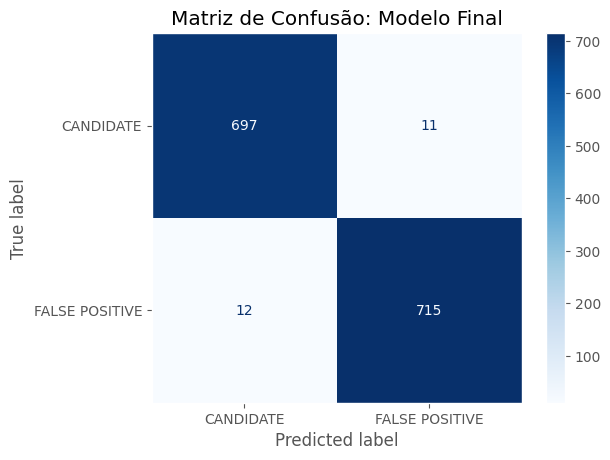

In [12]:
y_pred_final = modelo_final.predict(X_test_scaled)  # Gera predições finais no conjunto de teste

plt.figure(figsize=(8, 6))  # Define o tamanho da figura em polegadasConfusionMatrixDisplay.from_predictions(y_test, y_pred_final,  # Plota a Matriz de Confusão com cores azuis                                        display_labels=le.classes_, 
                                        cmap='Blues')
plt.title('Matriz de Confusão: Modelo Final')  # Define título do gráfico da Matriz de Confusãoplt.grid(False)  # Remove grade do gráfico para visualização limpaplt.show()  # Renderiza e exibe o gráfico

## 12. Classification Report
Métricas estatística de cada classe analisada

In [13]:
print("Relatório de Classificação Final")  # Imprime cabeçalho do relatório de classificaçãoprint(classification_report(y_test, y_pred_final, target_names=le.classes_))  # Exibe precision, recall e F1 por classe

Relatório de Classificação Final
                precision    recall  f1-score   support

     CANDIDATE       0.98      0.98      0.98       708
FALSE POSITIVE       0.98      0.98      0.98       727

      accuracy                           0.98      1435
     macro avg       0.98      0.98      0.98      1435
  weighted avg       0.98      0.98      0.98      1435



## 13. Curva ROC e AUC
Equilíbrio entre os erros do modelo e acertos

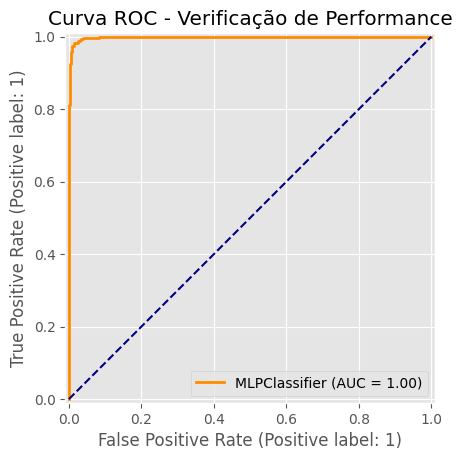

In [14]:
from sklearn.metrics import RocCurveDisplay  # Importa funções de avaliação de métricasimport matplotlib.pyplot as plt  # Importa Matplotlib para gráficos
RocCurveDisplay.from_estimator(  # Plota a curva ROC diretamente do modelo treinado    modelo_final, 
    X_test_scaled, 
    y_test, 
    curve_kwargs={'color': 'darkorange', 'lw': 2}
)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Traça a linha diagonal de chance aleatóriaplt.title('Curva ROC - Verificação de Performance')  # Define título do gráfico da Curva ROCplt.show()  # Renderiza e exibe o gráfico

## 14. Gráfico de Desempenho (Loss Curve)
Como a rede "aprendeu" durante o treinamento

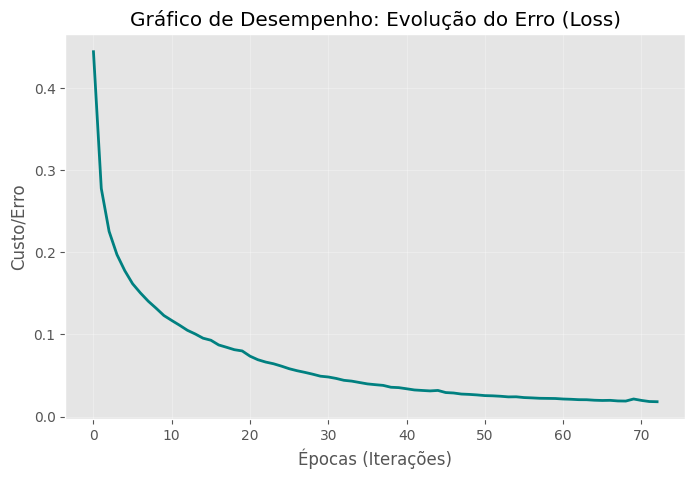

In [15]:
plt.figure(figsize=(8, 5))  # Define o tamanho da figura em polegadasplt.plot(modelo_final.loss_curve_, color='teal', lw=2)  # Plota a curva de evolução do erro (loss) do treinoplt.title('Gráfico de Desempenho: Evolução do Erro (Loss)')  # Define título do gráfico de desempenhoplt.xlabel('Épocas (Iterações)')  # Nomeia eixo X como épocas de treinamentoplt.ylabel('Custo/Erro')  # Nomeia eixo Y como valor do custo (erro)plt.grid(True, alpha=0.3)  # Adiciona grade ao gráfico com transparênciaplt.show()  # Renderiza e exibe o gráfico

## 15. Tabela Comparativa dos Modelos

In [16]:
print("Tabela Comparativa de Modelos:")  # Imprime cabeçalho da tabela comparativadisplay(results)  # Exibe a tabela comparativa formatada

Tabela Comparativa de Modelos:


,Modelo,Acurácia (Val),Configuração
0,Baseline (LR),93.4495%,N/A
1,MLP v1 (100),98.3275%,"(100,)"
2,"Exp A (100, 50)",95.8188%,"(100, 50)"
3,Exp B (200),96.5854%,"(200,)"
4,"Exp C (100, a=0.01)",98.3972%,"(100,) Alpha=0.01"
